# 1.KMeans 기초

## 1.1. 라이브러리 및 데이터 불러오기

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris

In [47]:
iris_data = load_iris()
iris_data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [48]:
# 보다 편리한 데이터 핸들링을 위해 컬럼값 변환
iris_df = pd.DataFrame(data=iris_data.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1.2. KMeans

In [49]:
from sklearn.cluster import KMeans

In [50]:
model_kmeans = KMeans(n_clusters=3,
                      random_state=1,
                      init='k-means++',         # 초기 중심점을 설정 방식. 가능하면 서로 떨어진 곳에 중심점을 잘 배치하자.
                      max_iter=300)             # 최대 300번까지만 하겠다.

In [51]:
model_kmeans.fit(iris_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [52]:
model_kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [53]:
iris_df['cluster'] = model_kmeans.labels_
iris_df['target'] = iris_data.target
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,cluster,target
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0


In [54]:
# 군집화 확인해보기
iris_df['cluster'].value_counts()

cluster
0    61
1    50
2    39
Name: count, dtype: int64

In [55]:
# 실제 target 확인
iris_df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [56]:
# target과 cluster 비교하기
iris_result = iris_df.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


# 2.임의 Clustering 데이터 생성 후 알고리즘 테스트

## 2.1. 라이브러리 불러오기

In [57]:
from sklearn.datasets import make_blobs

## 2.2. 데이터 생성

In [58]:
X, y = make_blobs(                              # make_blobs : 군집형 데이터를 생성하기 위한 함수              
                  n_samples=200,                # 총 200개의 데이터 샘플 생성
                  n_features=2,                 # 2개의 특성(2차원 좌표 형태)
                  centers=3,                    # 3개의 클러스터 중심을 생성
                  cluster_std=0.9,              # 각 클러스터의 표준편차 0.9(값이 클수록 데이터가 더 넓게 퍼짐)
                  shuffle=True,             
                  random_state=0)

In [59]:
print(X.shape, y.shape)

(200, 2) (200,)


In [60]:
X

array([[-1.71311732,  3.71004328],
       [ 0.66314914,  4.4445014 ],
       [ 1.11572276,  4.6441336 ],
       [-1.43895154,  3.44254057],
       [ 1.24468444,  5.49753463],
       [-0.83097633,  1.85238969],
       [ 2.52422591,  0.37945449],
       [ 1.60703832,  2.63424251],
       [ 1.09049096,  4.66557775],
       [-1.69849216,  2.5625177 ],
       [ 0.61341083,  5.40398789],
       [-0.90250818,  2.77426617],
       [ 1.66120403,  4.41329484],
       [ 1.33267612,  3.32003197],
       [ 0.15970155,  4.35053818],
       [-1.01634276,  2.71747467],
       [ 2.76296269,  0.47788647],
       [ 2.18302537,  0.61026808],
       [ 0.24443842,  2.75013299],
       [-3.35452003,  4.77592584],
       [-1.00623467,  3.23257127],
       [ 1.38498818,  0.15386898],
       [ 1.01745274,  4.13532186],
       [ 1.82879685,  4.16427824],
       [-3.55691182,  1.9976261 ],
       [-0.47623798,  4.11232108],
       [ 1.47601096, -1.10339918],
       [-2.21463354,  1.62386993],
       [-0.75477248,

In [61]:
y

array([2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 1,
       0, 0, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 1, 2, 1, 2, 2, 2,
       0, 0, 0, 2, 0, 0, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       1, 1, 2, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 0, 2,
       0, 1, 2, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1,
       0, 2, 1, 2, 0, 0, 0, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 1,
       1, 1, 0, 1, 1, 0, 1, 2, 2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 2, 2, 2,
       0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0, 1, 0, 1, 2, 2,
       0, 2, 0, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 1, 2, 1,
       0, 1])

In [62]:
cluster_df = pd.DataFrame(data=X,
                          columns=['ftr1', 'ftr2'])
cluster_df['target'] = y
cluster_df.head()

,ftr1,ftr2,target
0,-1.713117,3.710043,2
1,0.663149,4.444501,0
2,1.115723,4.644134,0
3,-1.438952,3.442541,2
4,1.244684,5.497535,0


- 시각화

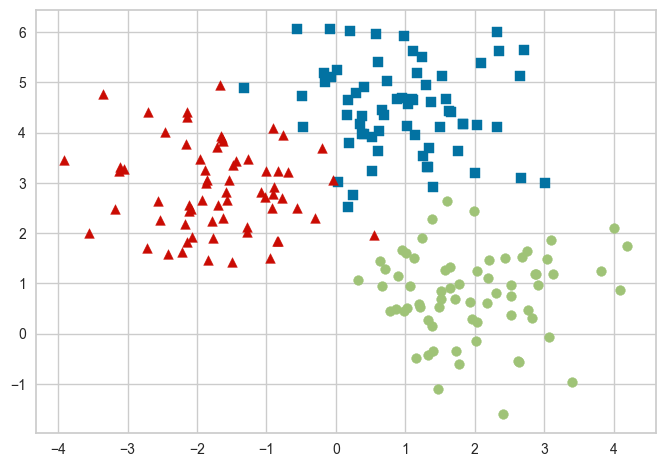

In [63]:
marker0 = cluster_df[cluster_df['target']==0].index
marker1 = cluster_df[cluster_df['target']==1].index
marker2 = cluster_df[cluster_df['target']==2].index

plt.scatter(x=cluster_df.loc[marker0,'ftr1'], y=cluster_df.loc[marker0,'ftr2'], marker='s') # 사각형
plt.scatter(x=cluster_df.loc[marker1,'ftr1'], y=cluster_df.loc[marker1,'ftr2'], marker='o') # 원형
plt.scatter(x=cluster_df.loc[marker2,'ftr1'], y=cluster_df.loc[marker2,'ftr2'], marker='^') # 삼각형

plt.show()

## 2.3.KMeans

**1) 선언하기**

In [64]:
model_kmeans = KMeans(n_clusters=3,
                      random_state=1,
                      init='k-means++',
                      max_iter=400)

**2) 학습하기**

In [65]:
model_kmeans.fit(cluster_df.drop('target', axis=1))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",400
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [66]:
model_kmeans.labels_

array([1, 2, 2, 1, 2, 1, 0, 0, 2, 1, 2, 1, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0,
       2, 2, 1, 2, 0, 1, 1, 1, 2, 2, 1, 2, 0, 0, 2, 0, 0, 1, 0, 1, 1, 1,
       2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 0, 2, 2, 1, 1, 2, 0, 0, 1,
       0, 0, 1, 0, 0, 2, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 2, 0, 0, 2, 2, 1,
       2, 0, 1, 1, 0, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 2, 1, 2, 0, 2, 1, 0,
       2, 1, 0, 2, 2, 2, 2, 0, 1, 1, 0, 0, 1, 2, 0, 2, 1, 0, 1, 2, 1, 0,
       0, 0, 2, 0, 0, 2, 0, 1, 1, 1, 2, 0, 0, 2, 1, 1, 0, 2, 0, 1, 1, 1,
       2, 0, 0, 0, 2, 2, 0, 1, 1, 1, 2, 2, 0, 1, 0, 0, 1, 0, 2, 0, 1, 1,
       2, 1, 2, 0, 2, 1, 0, 0, 0, 0, 1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 0,
       2, 0], dtype=int32)

In [67]:
cluster_df['cluster'] = model_kmeans.labels_
cluster_df.head()

,ftr1,ftr2,target,cluster
0,-1.713117,3.710043,2,1
1,0.663149,4.444501,0,2
2,1.115723,4.644134,0,2
3,-1.438952,3.442541,2,1
4,1.244684,5.497535,0,2


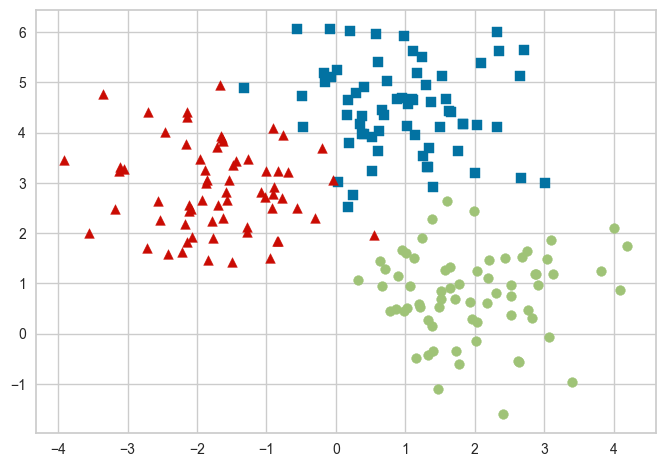

In [68]:
# 시각화
marker0 = cluster_df[cluster_df['target']==0].index
marker1 = cluster_df[cluster_df['target']==1].index
marker2 = cluster_df[cluster_df['target']==2].index

plt.scatter(x=cluster_df.loc[marker0,'ftr1'], y=cluster_df.loc[marker0,'ftr2'], marker='s') # 사각형
plt.scatter(x=cluster_df.loc[marker1,'ftr1'], y=cluster_df.loc[marker1,'ftr2'], marker='o') # 원형
plt.scatter(x=cluster_df.loc[marker2,'ftr1'], y=cluster_df.loc[marker2,'ftr2'], marker='^') # 삼각형

plt.show()

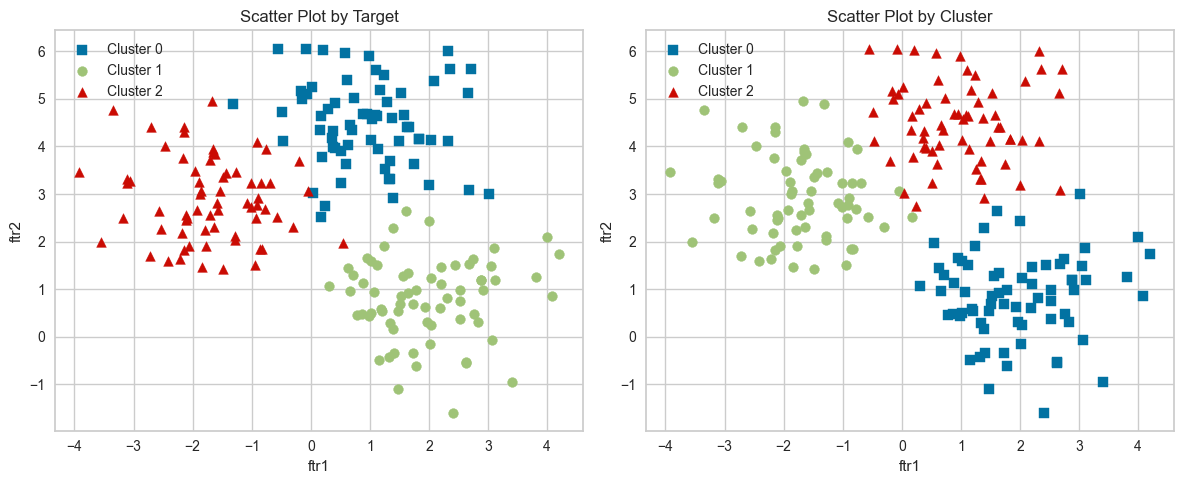

In [69]:
# Subplots 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 그래프에 필요한 설정값
titles = ['Scatter Plot by Target', 'Scatter Plot by Cluster']
columns = ['target', 'cluster']
markers = ['s', 'o', '^']
x_label = 'ftr1'
y_label = 'ftr2'

# 반복문으로 두 개의 서브플롯 생성
for i in range(2):
    for cluster_num in range(3):
        marker_index = cluster_df[cluster_df[columns[i]] == cluster_num].index
        axes[i].scatter(
            x=cluster_df.loc[marker_index, 'ftr1'],
            y=cluster_df.loc[marker_index, 'ftr2'],
            marker=markers[cluster_num],
            label=f'Cluster {cluster_num}'
        )
    axes[i].set_title(titles[i])
    axes[i].set_xlabel(x_label)
    axes[i].set_ylabel(y_label)
    axes[i].legend()

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()


## 2.4. 실루엣 분석

In [70]:
# %pip install yellowbrick
# %uv add yellowbrick

In [71]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [72]:
# iris의 모든 개별 데이터의 실루엣 계수값
# 실루엣 계수는 각 데이터 포인트 속한 군집의 품질을 평가하는 지표
score_sample = silhouette_samples(iris_data.data, iris_df['cluster'])
score_sample

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

In [73]:
iris_df['silhouette_coef'] = score_sample
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,cluster,target,silhouette_coef
0,5.1,3.5,1.4,0.2,1,0,0.852582
1,4.9,3.0,1.4,0.2,1,0,0.814916
2,4.7,3.2,1.3,0.2,1,0,0.828797
3,4.6,3.1,1.5,0.2,1,0,0.804352
4,5.0,3.6,1.4,0.2,1,0,0.848918


In [74]:
# 모든 데이터의 평균 실루엣 계수값
avg_score = silhouette_score(iris_data.data, iris_df['cluster'])
avg_score

0.5511916046195919

In [75]:
# 어떤 그룹이 군집이 잘 되고, 안 되었는지 확인
iris_df.groupby('cluster')['silhouette_coef'].mean()

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coef, dtype: float64

In [76]:
from yellowbrick.cluster import SilhouetteVisualizer

In [77]:
import sklearn
import yellowbrick

print('scikit-learn version', sklearn.__version__)
print('yellowbrick version:', yellowbrick.__version__)

scikit-learn version 1.8.0
yellowbrick version: 1.5


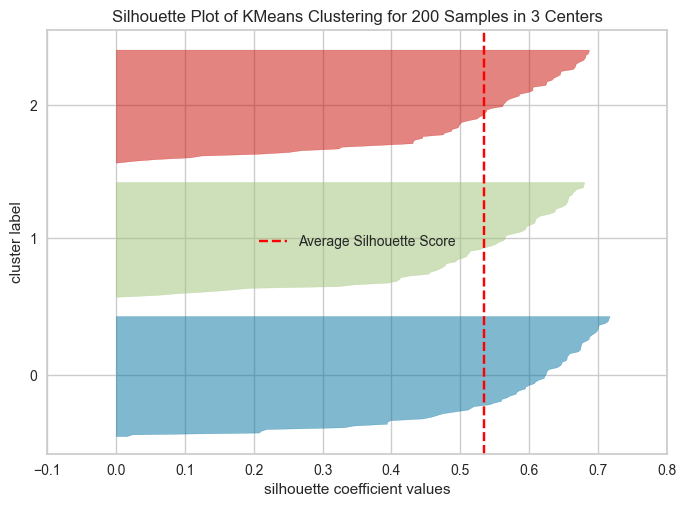

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [78]:
visualize = SilhouetteVisualizer(model_kmeans,
                                 colors='yellowbrick',
                                 force_model=True)

visualize.fit(X)
visualize.show()

# 3.클러스터별 평균 실루엣 계수의 시각화
- https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

In [79]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette(cluster_list, X_features):

    import matplotlib.cm as cm
    import math
    import matplotlib.pyplot as plt
    import numpy as np

    from sklearn.cluster import KMeans
    from sklearn.datasets import make_blobs
    from sklearn.metrics import silhouette_samples, silhouette_score
    

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_list)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_list):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        clusterer.fit(X_features)
        cluster_labels = clusterer.predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper),
                                   0,
                                   ith_cluster_sil_values,
                                   facecolor=color,
                                   edgecolor=color,
                                   alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

In [80]:
# make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
X, y = make_blobs(n_samples=500, 
                  n_features=2, 
                  centers=4, 
                  cluster_std=1,
                  center_box=(-10.90, 10.0),
                  shuffle=True,
                  random_state=1)

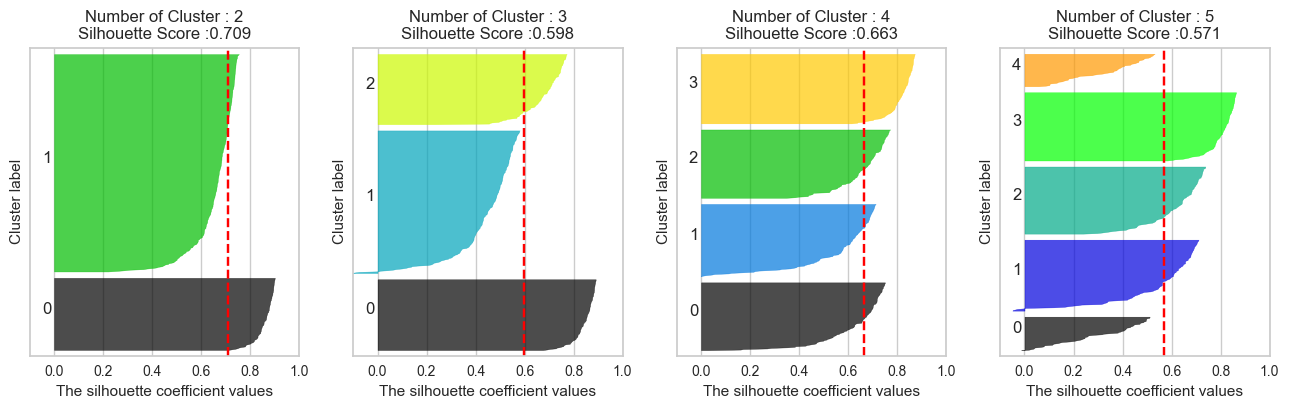

In [81]:
# 군집의 개수가 2개, 3개, 4개, 5개 일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([2,3,4,5], X)

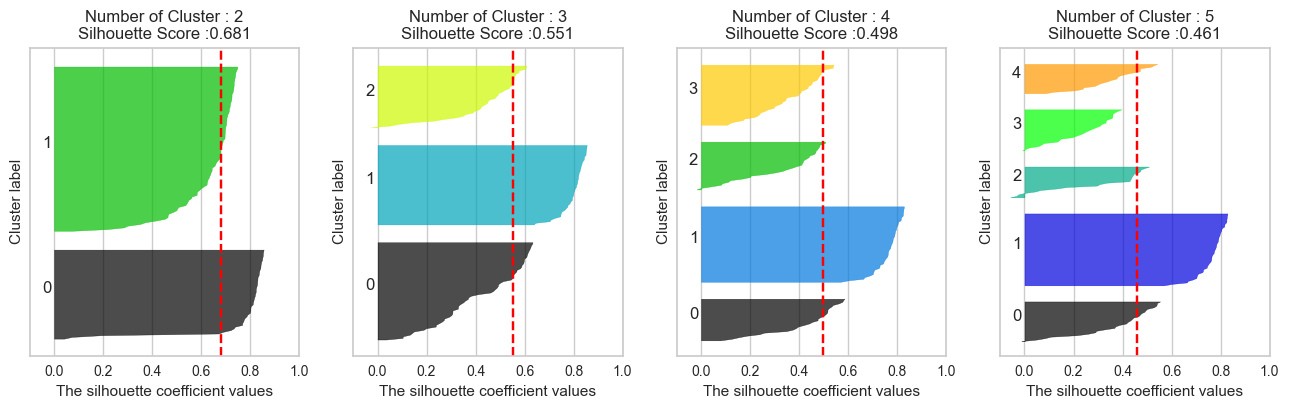

In [82]:
# 붓꽃 데이터를 이용해 k-Means 수행 시 최적의 군집 개수 알아보기
visualize_silhouette([2,3,4,5], iris_data.data)